## **Modelos com Implementação Própria, NumPy**

**Tarefa 2 do Trabalho Prático — Aprendizagem Profunda**

1. **Stratified K-Fold (K=5)** — Comparação robusta de modelos
2. **Baseline — Regressão Logística Multi-Classe** (Softmax Regression)
3. **DNN — Deep Neural Network** com várias arquiteturas e regularização
4. **Retreino do melhor modelo** e avaliação final no dataset do professor

### **1. Imports e Carregamento dos Dados**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os, time

sys.path.append(os.path.abspath('../src'))

from neuralnet import NeuralNetwork
from layers import DenseLayer, DropoutLayer
from activations import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy
from optimizer import Adam, SGD
from logisticregression import LogisticRegression
from utils import (prepare_text_data, prepare_fold_data, transform_new_texts,
                    stratified_k_fold)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

### **2. Carregamento dos Dados**

In [ ]:
print("A carregar os datasets...")

# Dataset principal (5000 textos — para K-Fold CV)
df_main = pd.read_csv('../data/dataset.csv', sep=';')
df_main.columns = df_main.columns.str.lower()
textos = df_main['text'].tolist()
labels = df_main['label'].tolist()

# Dataset de teste (125 textos do professor)
df_test = pd.read_csv('../data/dataset-test.csv', sep=';')
df_test.columns = df_test.columns.str.lower()
textos_test = df_test['text'].tolist()
labels_test = df_test['label'].tolist()

print(f"  Dataset principal: {len(textos)} textos")
print(f"  Dataset teste (prof): {len(textos_test)} textos")
print(f"  Classes: {sorted(set(labels))}")

A carregar os datasets...
  Dataset principal: 5000 textos
  Dataset teste (prof): 125 textos
  Classes: ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']


### **3. Validação Cruzada — Stratified K-Fold (K=5)**

Cada modelo é avaliado com 5-Fold CV estratificado. Em cada fold:
- TF-IDF é ajustado **apenas** nos dados de treino do fold (sem data leakage)
- O modelo treina e é avaliado no fold de validação
- Reportamos **média ± desvio padrão** da accuracy nos 5 folds

In [3]:
K = 5
FEAT_PARAMS = dict(max_features=1500, char_features=1500, ngram_range=(1, 2), stop_words=set())

def kfold_baseline(textos, labels, k=K, lr_rate=0.05, l2=0.001, epochs=200):
    """K-Fold CV para a Regressão Logística baseline."""
    accs = []
    for fold, (train_idx, val_idx) in enumerate(stratified_k_fold(labels, n_splits=k)):
        texts_tr = [textos[i] for i in train_idx]
        texts_vl = [textos[i] for i in val_idx]
        labels_tr = [labels[i] for i in train_idx]
        labels_vl = [labels[i] for i in val_idx]

        X_tr, Y_tr, X_vl, Y_vl, _, enc = prepare_fold_data(
            texts_tr, labels_tr, texts_vl, labels_vl, **FEAT_PARAMS)

        np.random.seed(42)
        model = LogisticRegression(X_tr.shape[1], Y_tr.shape[1], lr_rate, l2)
        model.fit(X_tr, Y_tr, epochs=epochs, batch_size=64, verbose=False, patience=None)
        _, acc = model.evaluate(X_vl, Y_vl)
        accs.append(acc)
        print(f"  Fold {fold+1}: {acc:.2%}")
    return np.array(accs)

def kfold_dnn(textos, labels, camadas_config, k=K, epochs=200, batch_size=128,
              patience=15, lr=0.0001):
    """K-Fold CV para uma DNN."""
    accs = []
    for fold, (train_idx, val_idx) in enumerate(stratified_k_fold(labels, n_splits=k)):
        texts_tr = [textos[i] for i in train_idx]
        texts_vl = [textos[i] for i in val_idx]
        labels_tr = [labels[i] for i in train_idx]
        labels_vl = [labels[i] for i in val_idx]

        X_tr, Y_tr, X_vl, Y_vl, _, enc = prepare_fold_data(
            texts_tr, labels_tr, texts_vl, labels_vl, **FEAT_PARAMS)

        np.random.seed(42)
        adam = Adam(learning_rate=lr)
        nn = NeuralNetwork(loss_func=CategoricalCrossEntropy())
        prev = X_tr.shape[1]
        for n_units, dropout, l2 in camadas_config:
            nn.add(DenseLayer(prev, n_units, optimizer=adam, l2_lambda=l2))
            nn.add(ReLUActivation())
            if dropout > 0: nn.add(DropoutLayer(rate=dropout))
            prev = n_units
        nn.add(DenseLayer(prev, Y_tr.shape[1], optimizer=adam))
        nn.add(SoftmaxActivation())

        nn.fit(X_tr, Y_tr, epochs=epochs, batch_size=batch_size,
               verbose=False, X_val=X_vl, Y_val=Y_vl, patience=patience)
        _, acc = nn.evaluate(X_vl, Y_vl)
        accs.append(acc)
        print(f"  Fold {fold+1}: {acc:.2%}")
    return np.array(accs)

print("Funções de K-Fold definidas.")

Funções de K-Fold definidas.


### **3.1 Resultados do K-Fold**

In [4]:
print("=" * 60)
print("Stratified 5-Fold Cross-Validation")
print("=" * 60)

cv_results = {}

# Baseline LR
print("\nBaseline LR:")
accs = kfold_baseline(textos, labels)
cv_results["Baseline LR"] = accs
print(f"  → Média: {accs.mean():.2%} ± {accs.std():.2%}")

# DNN configs
dnn_configs = {
    "DNN Moderate (128→32)": [(128, 0.3, 0.0), (32, 0.3, 0.0)],
    "DNN Dropout (128→32)":  [(128, 0.5, 0.0), (32, 0.5, 0.0)],
    "DNN D+L2 (128→32)":    [(128, 0.5, 0.01), (32, 0.5, 0.01)],
    "DNN L2 Only (128→32)": [(128, 0.0, 0.01), (32, 0.0, 0.01)],
}

for nome, config in dnn_configs.items():
    print(f"\n{nome}:")
    accs = kfold_dnn(textos, labels, config)
    cv_results[nome] = accs
    print(f"  → Média: {accs.mean():.2%} ± {accs.std():.2%}")

Stratified 5-Fold Cross-Validation

Baseline LR:
  Fold 1: 75.20%
  Fold 2: 74.80%
  Fold 3: 79.30%
  Fold 4: 74.70%
  Fold 5: 77.00%
  → Média: 76.20% ± 1.76%

DNN Moderate (128→32):
  Fold 1: 85.20%
  Fold 2: 84.00%
  Fold 3: 86.70%
  Fold 4: 85.90%
  Fold 5: 84.40%
  → Média: 85.24% ± 0.98%

DNN Dropout (128→32):
  Fold 1: 84.50%
  Fold 2: 83.50%
  Fold 3: 86.70%
  Fold 4: 85.60%
  Fold 5: 85.00%
  → Média: 85.06% ± 1.07%

DNN D+L2 (128→32):
  Fold 1: 81.00%
  Fold 2: 82.10%
  Fold 3: 83.00%
  Fold 4: 81.90%
  Fold 5: 81.70%
  → Média: 81.94% ± 0.65%

DNN L2 Only (128→32):
  Fold 1: 82.80%
  Fold 2: 81.30%
  Fold 3: 85.10%
  Fold 4: 83.10%
  Fold 5: 83.60%
  → Média: 83.18% ± 1.23%


In [5]:
# Tabela resumo do K-Fold
rows = []
for nome, accs in cv_results.items():
    rows.append({"Modelo": nome, "Média": f"{accs.mean():.2%}",
                 "Std": f"±{accs.std():.2%}",
                 "Min": f"{accs.min():.2%}", "Max": f"{accs.max():.2%}"})

df_cv = pd.DataFrame(rows).sort_values('Média', ascending=False)
print("\n" + "=" * 60)
print("RESUMO K-FOLD CV")
print("=" * 60)
print(df_cv.to_string(index=False))


RESUMO K-FOLD CV
               Modelo  Média    Std    Min    Max
DNN Moderate (128→32) 85.24% ±0.98% 84.00% 86.70%
 DNN Dropout (128→32) 85.06% ±1.07% 83.50% 86.70%
 DNN L2 Only (128→32) 83.18% ±1.23% 81.30% 85.10%
    DNN D+L2 (128→32) 81.94% ±0.65% 81.00% 83.00%
          Baseline LR 76.20% ±1.76% 74.70% 79.30%


### **4. Retreino do Melhor Modelo + Avaliação no Teste**

Com base nos resultados do K-Fold, retreinamos o melhor modelo com
um split 80/20 (para early stopping) e avaliamos no dataset do professor.

In [6]:
# Retreinar com split 80/20 para ter early stopping
print("A preparar dados para retreino...")
X_train, Y_train, X_val, Y_val, transformers, encoder = prepare_text_data(
    textos, labels,
    max_features=1500, char_features=1500, val_size=0.20,
    use_stratify=True, ngram_range=(1, 2), stop_words=set()
)

X_test = transform_new_texts(textos_test, transformers)
Y_test = encoder.transform(np.array(labels_test))

input_dim = X_train.shape[1]
output_dim = Y_train.shape[1]
class_names = encoder.classes

print(f"  Treino: {X_train.shape} | Val: {X_val.shape} | Teste: {X_test.shape}")

# Selecionar a melhor config do K-Fold
melhor_nome = df_cv.iloc[0]['Modelo']
print(f"\nMelhor modelo pelo K-Fold: {melhor_nome}")

# Baseline?
if melhor_nome == "Baseline LR":
    np.random.seed(42)
    lr_model = LogisticRegression(input_dim, output_dim, 0.05, 0.001)
    t0 = time.time()
    lr_model.fit(X_train, Y_train, epochs=200, batch_size=64, verbose=True,
                 X_val=X_val, Y_val=Y_val, patience=15)
    tempo = time.time() - t0
    train_loss, train_acc = lr_model.evaluate(X_train, Y_train)
    val_loss, val_acc = lr_model.evaluate(X_val, Y_val)
    test_loss, test_acc = lr_model.evaluate(X_test, Y_test)
    melhor_modelo_obj = lr_model
    melhor_tipo = 'Baseline LR'
else:
    # Encontrar config correspondente
    config = dnn_configs[melhor_nome]
    np.random.seed(42)
    adam = Adam(learning_rate=0.0001)
    nn_model = NeuralNetwork(loss_func=CategoricalCrossEntropy())
    prev = input_dim
    for n_units, dropout, l2 in config:
        nn_model.add(DenseLayer(prev, n_units, optimizer=adam, l2_lambda=l2))
        nn_model.add(ReLUActivation())
        if dropout > 0: nn_model.add(DropoutLayer(rate=dropout))
        prev = n_units
    nn_model.add(DenseLayer(prev, output_dim, optimizer=adam))
    nn_model.add(SoftmaxActivation())

    t0 = time.time()
    nn_model.fit(X_train, Y_train, epochs=300, batch_size=128, verbose=True,
                 X_val=X_val, Y_val=Y_val, patience=15)
    tempo = time.time() - t0
    train_loss, train_acc = nn_model.evaluate(X_train, Y_train)
    val_loss, val_acc = nn_model.evaluate(X_val, Y_val)
    test_loss, test_acc = nn_model.evaluate(X_test, Y_test)
    melhor_modelo_obj = nn_model
    melhor_tipo = melhor_nome

print(f"\n🏆 Resultados finais — {melhor_tipo}:")
print(f"  Treino    — Acc: {train_acc:.2%}")
print(f"  Validação — Acc: {val_acc:.2%}")
print(f"  Teste     — Acc: {test_acc:.2%}")
print(f"  Tempo: {tempo:.1f}s")

A preparar dados para retreino...
  Treino: (4000, 3013) | Val: (1000, 3013) | Teste: (125, 3013)

Melhor modelo pelo K-Fold: DNN Moderate (128→32)
Epoch 1/300 | Loss: 1.5430 | Val Loss: 1.5487 | Train Acc: 41.05% | Val Acc: 37.00%
Epoch 11/300 | Loss: 0.9297 | Val Loss: 0.9858 | Train Acc: 66.92% | Val Acc: 61.30%
Epoch 21/300 | Loss: 0.6814 | Val Loss: 0.7829 | Train Acc: 79.95% | Val Acc: 72.30%
Epoch 31/300 | Loss: 0.5027 | Val Loss: 0.6469 | Train Acc: 87.42% | Val Acc: 78.50%
Epoch 41/300 | Loss: 0.3709 | Val Loss: 0.5526 | Train Acc: 91.95% | Val Acc: 81.40%
Epoch 51/300 | Loss: 0.2711 | Val Loss: 0.4893 | Train Acc: 94.55% | Val Acc: 83.10%
Epoch 61/300 | Loss: 0.2003 | Val Loss: 0.4514 | Train Acc: 96.53% | Val Acc: 83.80%
Epoch 71/300 | Loss: 0.1491 | Val Loss: 0.4277 | Train Acc: 97.80% | Val Acc: 84.70%
Epoch 81/300 | Loss: 0.1113 | Val Loss: 0.4154 | Train Acc: 98.80% | Val Acc: 84.90%
Epoch 91/300 | Loss: 0.0830 | Val Loss: 0.4149 | Train Acc: 99.30% | Val Acc: 85.00%
Epo

### **5. Avaliação Final**

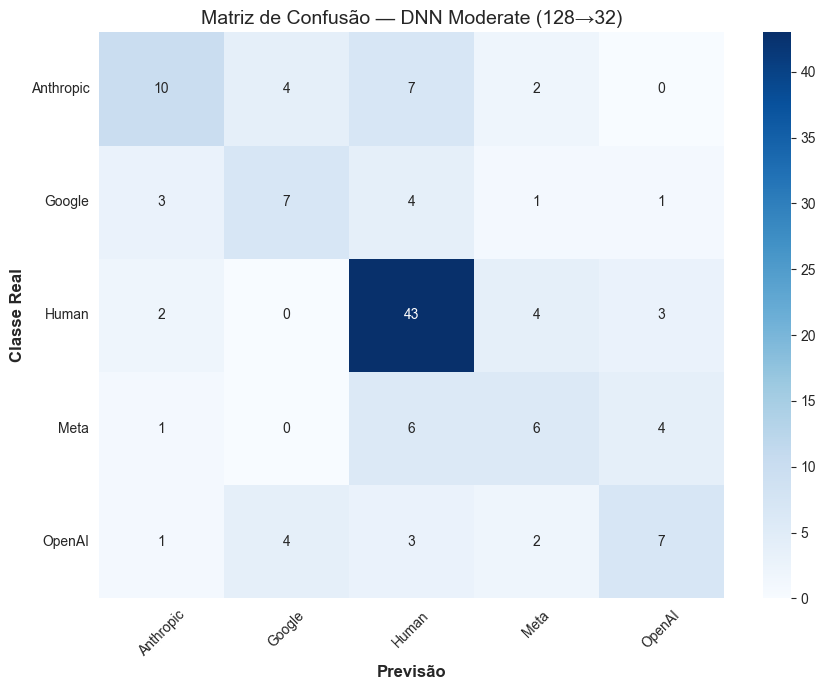


Classification Report — DNN Moderate (128→32):
              precision    recall  f1-score   support

   Anthropic       0.59      0.43      0.50        23
      Google       0.47      0.44      0.45        16
       Human       0.68      0.83      0.75        52
        Meta       0.40      0.35      0.38        17
      OpenAI       0.47      0.41      0.44        17

    accuracy                           0.58       125
   macro avg       0.52      0.49      0.50       125
weighted avg       0.57      0.58      0.57       125



In [7]:
from sklearn.metrics import confusion_matrix, classification_report

if melhor_tipo == 'Baseline LR':
    y_pred_test = melhor_modelo_obj.predict(X_test)
else:
    melhor_modelo_obj.set_training(False)
    y_pred_test = np.argmax(melhor_modelo_obj.predict(X_test), axis=1)
y_true_test = np.argmax(Y_test, axis=1)

cm = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão', fontsize=12, fontweight='bold')
plt.ylabel('Classe Real', fontsize=12, fontweight='bold')
plt.title(f'Matriz de Confusão — {melhor_tipo}', fontsize=14)
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

print(f"\nClassification Report — {melhor_tipo}:")
print(classification_report(y_true_test, y_pred_test, target_names=class_names, zero_division=0))

### **6. Guardar o Modelo**

In [8]:
import pickle

modelo_para_guardar = {
    'modelo_tipo': melhor_tipo,
    'transformers': transformers,
    'encoder': encoder,
    'class_names': class_names,
}

if melhor_tipo == 'Baseline LR':
    modelo_para_guardar['weights'] = melhor_modelo_obj.weights
    modelo_para_guardar['biases'] = melhor_modelo_obj.biases
else:
    pesos = []
    for layer in melhor_modelo_obj.layers:
        if hasattr(layer, 'get_weights'):
            pesos.append(layer.get_weights())
        else:
            pesos.append(None)
    modelo_para_guardar['pesos_camadas'] = pesos

caminho = '../models/numpy.pkl'
os.makedirs('../models', exist_ok=True)
with open(caminho, 'wb') as f:
    pickle.dump(modelo_para_guardar, f)
print(f"✅ Modelo guardado em '{caminho}'")

✅ Modelo guardado em '../models/numpy.pkl'
